## traning and Data-efficient Image Transformers (DeIT) : An Meta labs paper on Vision Bases Transformers (ViT)
### paper link : [https://arxiv.org/abs/2012.12877](http://)
### Dataset Used :  Flowers102 (importing from torchvision)
### Pretrained CNN models : resnet50
### Classes in Dataset : 102 


In [1]:
! pip install torchvision 
! pip install timm 
! pip install tqdm 

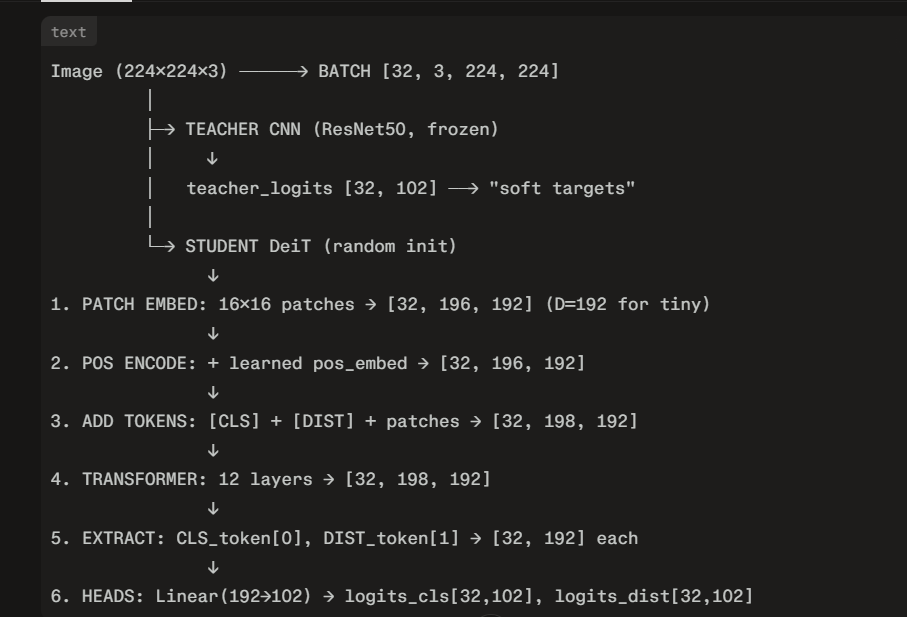

In [2]:
import torch 
import numpy as np 
import torchvision 
import torchvision.transforms as transforms 
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim 
from tqdm.notebook import tqdm   
import timm
import math
import torch.nn.functional as F

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:{device}")

Device:cuda


In [4]:
transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
train_dataset = torchvision.datasets.Flowers102(
                    root='./data', split='train', transform=transforms, download=True
                )

val_dataset = torchvision.datasets.Flowers102(
                    root='./data', split='val', transform=transforms, download=True
                )

test_dataset = torchvision.datasets.Flowers102(
                    root='./data', split='test', transform=transforms, download=True
                )

100%|██████████| 345M/345M [00:12<00:00, 28.3MB/s] 
100%|██████████| 502/502 [00:00<00:00, 1.56MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 12.3MB/s]


In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [7]:
print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images") 
print(f"Test:  {len(test_dataset)} images")

Train: 1020 images
Val:   1020 images
Test:  6149 images


In [8]:
## Testing code to test the shape of image 
for image,label in train_loader:
    break
print(image.shape)
print(label.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## Importing pretrained CNN Model

In [9]:
## Class in flower102 dataset
oxford_flowers_classes = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea", "english marigold",
    "tiger lily", "moon orchid", "bird of paradise", "monkshood", "globe thistle",
    "snapdragon", "colt's foot", "king protea", "spear thistle", "yellow iris",
    "globe-flower", "purple coneflower", "peruvian lily", "balloon flower", "giant white arum lily",
    "fire lily", "pincushion flower", "fritillary", "red ginger", "grape hyacinth",
    "corn poppy", "prince of wales feathers", "stemless gentian", "artichoke", "sweet william",
    "carnation", "garden phlox", "love in the mist", "mexican aster", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort", "siam tulip", "lenten rose",
    "barbeton daisy", "daffodil", "sword lily", "poinsettia", "bolero deep blue", "wallflower",
    "marigold", "buttercup", "oxeye daisy", "common dandelion", "petunia", "wild pansy",
    "primula", "sunflower", "pelargonium", "bishop of llandaff", "gaura", "geranium",
    "orange dahlia", "pink-yellow dahlia", "cautleya spicata", "japanese anemone", "black-eyed susan",
    "silverbush", "californian poppy", "osteospermum", "spring crocus", "bearded iris",
    "windflower", "tree poppy", "gazania", "azalea", "water lily",
    "rose", "thorn apple", "morning glory", "passion flower", "lotus",
    "toad lily", "anthurium", "frangipani", "clematis", "hibiscus",
    "columbine", "desert-rose", "tree mallow", "magnolia", "cyclamen",
    "watercress", "canna lily", "hippeastrum", "bee balm", "ball moss",
    "foxglove", "bougainvillea", "camellia", "mallow", "mexican petunia",
    "bromelia", "blanket flower", "trumpet creeper", "blackberry lily"
]
print(oxford_flowers_classes.__len__())

102


In [10]:
teacher_model = timm.create_model("resnet50",pretrained=True,num_classes=102)
teacher_model.to(device).eval()

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

## Building : Patches head

In [11]:
## image = {32,3,224,224}
## patches = 196
## patch_size = 16
## image = (32,768,14,14) -> projection 
## image = (32,768,196) -> flatten 
## image = (32,196,768) -> reshape  

In [12]:
class PatchEmbedding(nn.Module):
    def __init__(self,patch_size,embedding_dim):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels = 3,
            out_channels = embedding_dim,
            stride = patch_size,
            kernel_size = patch_size
        )
        
    def forward(self,x):
        x = self.proj(x)
        x = x.flatten(2,-1) # it means that first two keep same then multiply rest 
        x = x.transpose(2,1)
        return x

## here it means that eacg patch (14x14) is converted into 768 dim vector 

In [13]:
patch_size = 16 
num_patches = 196
embedding_dim = 768
patch_embedding = PatchEmbedding(patch_size,embedding_dim)
image_patched = patch_embedding(image)
patch_embedding(image).shape

torch.Size([32, 196, 768])

## Positional Encoding 

In [14]:
## image = (32,196,768)
## pe = (196,768) -> for each image ans positional encoder image in buffer
## div = 
## position = 
## pe = (196,768)
## positionally encoded = (32,196,768)
## image = (32,196,768)

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self,num_patches,embedding_dim):
        super().__init__()
        self.num_patches = num_patches 
        pe = torch.zeros(num_patches,embedding_dim) # (196,768)
        div = torch.exp(torch.arange(0,embedding_dim,2).float() * -(math.log(1000.0)/embedding_dim)) # (384)
        positions = torch.arange(0,num_patches).float().unsqueeze(1) # (196,1)
        pe[:,0::2] = torch.sin(positions*div)
        pe[:,1::2] = torch.cos(positions*div)
        ## (196,768)
        ## print(pe.shape)
        pe = pe.unsqueeze(0) # (1,196,768) -> for batch
        ## print(pe.shape)
        self.register_buffer("pe",pe)
        
    def forward(self,x):
        return x + self.pe[:,:self.num_patches,:].requires_grad_(False)

In [16]:
positions = PositionalEncoding(num_patches,embedding_dim)
positioned_image = positions(image_patched)
positions(image_patched).shape

torch.Size([32, 196, 768])

## Adding Cls and Dist Token 

In [17]:
cls_token = torch.zeros(1,1,embedding_dim)
dist_token = torch.zeros(1,1,embedding_dim)
print(cls_token.shape,dist_token.shape)

torch.Size([1, 1, 768]) torch.Size([1, 1, 768])


In [18]:
token = torch.cat([cls_token,dist_token],dim=1) # (1,2,768)
x = torch.cat([token.expand(positioned_image.size(0),-1,-1),positioned_image],dim=1)  # (1,2,768) cat (32,196,768) = (32,198,768)
x.shape

torch.Size([32, 198, 768])

## Building : Encoder Only Models (Transformer encoder head)

In [58]:
## Building Multihead attention block 
class MultiHeadAttention(nn.Module):
    def __init__(self,num_patches,embedding_dim):
        super().__init__()
        self.heads = 12
        self.d_k = 64
        self.Q = nn.Linear(embedding_dim,embedding_dim)
        self.K = nn.Linear(embedding_dim,embedding_dim)
        self.V = nn.Linear(embedding_dim,embedding_dim)
        self.softmax = nn.Softmax(dim=-1)
        self.linear_fc = nn.Linear(embedding_dim,embedding_dim)
        
    def forward(self,x):
        batch,patches,embedding_dim = x.shape
        q = self.Q(x).view(batch,patches,self.heads,self.d_k).transpose(1,2) # (32,12,196,64)
        k = self.K(x).view(batch,patches,self.heads,self.d_k).transpose(1,2)
        v = self.V(x).view(batch,patches,self.heads,self.d_k).transpose(1,2)
        k_t = k.transpose(-2,-1)
        attention = self.softmax((q @ k_t)/math.sqrt(self.d_k)) @ v # ((32,12,196,64)
        out = attention.transpose(1,2).contiguous().view(batch,patches,embedding_dim)
        return self.linear_fc(out)

In [59]:
attention = MultiHeadAttention(num_patches+2,embedding_dim)
output = attention(x)
output.shape

torch.Size([32, 198, 768])

In [21]:
## Building Feed Forward Layer 
class FeedForwardNetwork(nn.Module):
    def __init__(self,num_patches,embedding_dim):
        super().__init__()
        # (32,198,768)
        self.layer = nn.Sequential(
            nn.Linear(embedding_dim,2048),
            nn.ReLU(),
            nn.Linear(2048,embedding_dim)
        )
        
    def forward(self,x):
        return self.layer(x)


In [22]:
fnn = FeedForwardNetwork(198,embedding_dim)
fnn(output).shape

torch.Size([32, 198, 768])

In [23]:
alpha = nn.Parameter(torch.ones(1))
beta = nn.Parameter(torch.ones(1))
mean = x.mean(dim=-1,keepdim=True) # not to remove the dimension 
std = x.std(dim=-1,keepdim=True)
mean.shape,std.shape
((alpha * ((x-mean)/(std+0.001))) +beta).shape

torch.Size([32, 198, 768])

In [24]:
## Building Layer Norm layer 
class LayerNorm(nn.Module):
    def __init__(self,):
        super().__init__()
        self.eps = 0.001
        self.alpha = nn.Parameter(torch.ones(1))
        self.beta = nn.Parameter(torch.ones(1))
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True) # not to remove the dimension 
        std = x.std(dim=-1,keepdim=True)
        return (self.alpha * ((x-mean)/(std+self.eps))) + self.beta
        ## inside part = (32,198,1) * (32,198,768) + (32,198,768) = (32,198,768)

In [25]:
### Building Residual
class ResidualBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = LayerNorm()
    def forward(self,x,Sublayer):
        return x + Sublayer(self.layer(x))

In [26]:
class EncoderBlock(nn.Module):
  def __init__(self,attention:MultiHeadAttention,fnn:FeedForwardNetwork,num_patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.num_patches = num_patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
  def forward(self,X):
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

In [27]:
class Encoder(nn.Module):
    def __init__(self,layers: nn.ModuleList):
        super().__init__()
        self.layers = layers
        self.norm = LayerNorm()

    def forward(self,x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

## Building : Classification layer

In [28]:
x = torch.zeros(32,198,768)
x[:,0].shape

torch.Size([32, 768])

In [29]:
class DeitClassification(nn.Module):
    def __init__(self,embed_dim,num_class=102):
        super().__init__()
        ## tokens cls and dist are with dim = (1,1,768)
        self.cls_head = nn.Linear(embed_dim,num_class)
        self.dist_head = nn.Linear(embed_dim,num_class)
        
    def forward(self,x):
        ## x = (32,198,768)
        cls_token = x[:,0]
        dist_token = x[:,1]
        cls_logits = self.dist_head(cls_token)
        dist_logits = self.dist_head(cls_token)
        return cls_logits , dist_logits

## Building : Data efficient image transformer loss 

### Loss function 
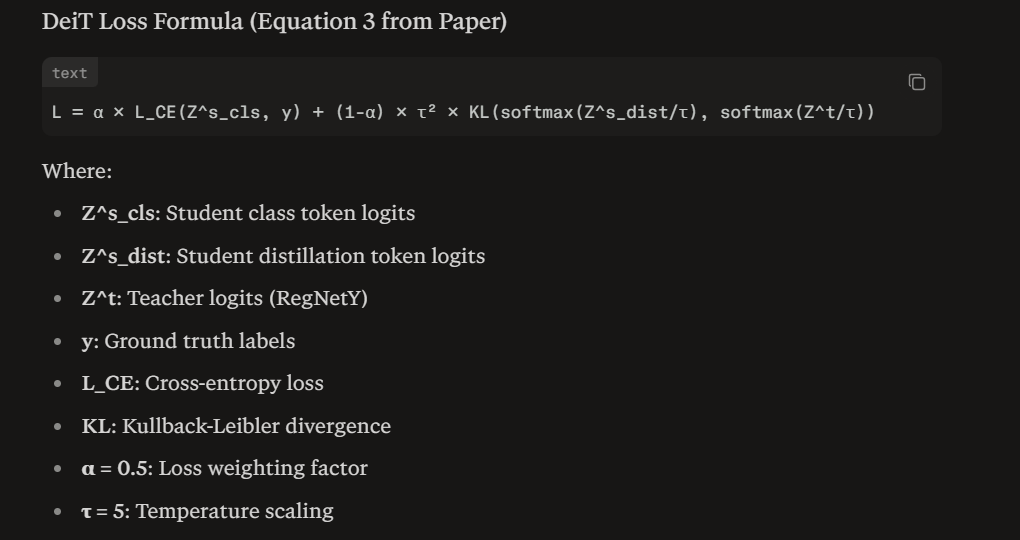

In [41]:
class DeitLoss(nn.Module):
    def __init__(self,alpha=0.5,T=5.0):
        super().__init__()
        self.alpha = alpha  # Weight between CE and distillation (0.5 from paper)
        self.T = T          # Temperature scaling (5.0 from paper)
        self.L_CE = nn.CrossEntropyLoss()
    def forward(self,cls_logits,dist_logits,teacher_logits,labels):
        ce_loss = self.L_CE(cls_logits,labels)
        ## here below the the dist loss and the cnn loss are compared 
        soft_teacher = F.softmax(teacher_logits/self.T,dim=1)
        soft_student = F.log_softmax(dist_logits/self.T,dim=1)
        dist_loss = F.kl_div(soft_student,soft_teacher,reduction='batchmean') ** (self.T**2)
        return self.alpha*ce_loss + (1-self.alpha)*dist_loss

### Building : Model

In [42]:
patch_size = 16
num_patches = 196
embedding_dim = 768
num_class = 102

In [60]:
patch_embedding = PatchEmbedding(patch_size,embedding_dim)
positional_encoding = PositionalEncoding(num_patches,embedding_dim)
attention = MultiHeadAttention(num_patches,embedding_dim)
fnn = FeedForwardNetwork(num_patches,embedding_dim)
encoder_block = EncoderBlock(attention,fnn,num_patches,embedding_dim)
encoder = Encoder(nn.ModuleList([encoder_block for _ in range(12)]))
classifier = DeitClassification(embedding_dim,num_class)

In [61]:
encoder

Encoder(
  (layers): ModuleList(
    (0-11): 12 x EncoderBlock(
      (attention): MultiHeadAttention(
        (Q): Linear(in_features=768, out_features=768, bias=True)
        (K): Linear(in_features=768, out_features=768, bias=True)
        (V): Linear(in_features=768, out_features=768, bias=True)
        (softmax): Softmax(dim=-1)
        (linear_fc): Linear(in_features=768, out_features=768, bias=True)
      )
      (fnn): FeedForwardNetwork(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=2048, bias=True)
          (1): ReLU()
          (2): Linear(in_features=2048, out_features=768, bias=True)
        )
      )
      (residual): ModuleList(
        (0-1): 2 x ResidualBlock(
          (layer): LayerNorm()
        )
      )
    )
  )
  (norm): LayerNorm()
)

In [62]:
class Deit(nn.Module):
    def __init__(self,encoder:Encoder,head:DeitClassification,teacher:teacher_model,patches:PatchEmbedding,positional:PositionalEncoding,device,num_patches,embedding_dim):
        super().__init__()
        self.encoder = encoder
        self.head = head
        self.teacher = teacher
        self.num_patches = num_patches
        self.embedding_dim = embedding_dim
        self.patches = patches
        self.positional = positional
        self.cls_token = torch.zeros(1,1,self.embedding_dim).to(device)
        self.dist_token = torch.zeros(1,1,self.embedding_dim).to(device)
        
    def forward(self,x):
        x = self.patches(x)
        x = self.positional(x)
        cls_token = self.cls_token.expand(x.size(0),-1,-1)
        dist_token = self.dist_token.expand(x.size(0),-1,-1)
        x = torch.cat([cls_token,dist_token,x],dim=1)
        x = self.encoder(x)
        cls_logits,dist_logits = self.head(x)
        return cls_logits,dist_logits

In [63]:
model = Deit(
        encoder,
        classifier,
        teacher_model,
        patch_embedding,
        positional_encoding,
        device,
        num_patches,
        embedding_dim
    )

In [64]:
model.to(device)

Deit(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-11): 12 x EncoderBlock(
        (attention): MultiHeadAttention(
          (Q): Linear(in_features=768, out_features=768, bias=True)
          (K): Linear(in_features=768, out_features=768, bias=True)
          (V): Linear(in_features=768, out_features=768, bias=True)
          (softmax): Softmax(dim=-1)
          (linear_fc): Linear(in_features=768, out_features=768, bias=True)
        )
        (fnn): FeedForwardNetwork(
          (layer): Sequential(
            (0): Linear(in_features=768, out_features=2048, bias=True)
            (1): ReLU()
            (2): Linear(in_features=2048, out_features=768, bias=True)
          )
        )
        (residual): ModuleList(
          (0-1): 2 x ResidualBlock(
            (layer): LayerNorm()
          )
        )
      )
    )
    (norm): LayerNorm()
  )
  (head): DeitClassification(
    (cls_head): Linear(in_features=768, out_features=102, bias=True)
    (dist_head): Linear(in_

In [65]:
cls,dist = model(image.to(device))
cls.shape , dist.shape

(torch.Size([32, 102]), torch.Size([32, 102]))


## Building : Optimizers,Criterion,Schedular 

In [66]:
criterion = DeitLoss(0.5,5.0)
optimizer = optim.AdamW(model.parameters(),lr=1e-4,weight_decay=0.001)
lr_schedular = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

## Training loop

In [67]:
training_loss = {}
validation_loss = {}

In [69]:
num_epochs = 20
for epoch in tqdm(range(num_epochs),desc="Training loop"):
    print("--"*40)
    model.train()
    total_loss = 0
    train_loss = 0
    for batch,label in tqdm(train_loader,desc=f"Epoch {epoch+1}/{num_epochs}",leave=False):
        batch,label = batch.to(device),label.to(device)
        optimizer.zero_grad()
        ## teacher prediction 
        with torch.no_grad():
            teacher_logits = teacher_model(batch)
        ## loop 
        cls,dist = model(batch)
        loss = criterion(cls,dist,teacher_logits,label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)
    training_loss[epoch] = train_loss
    print(f"Epoch : {epoch} Training Loss:{train_loss}")
    model.eval()
    val_loss = 0
    total_loss = 0
    with torch.no_grad():
        for batch,label in tqdm(val_loader,desc=f"Epoch {epoch+1}/{num_epochs}",leave=False):
            batch,label = batch.to(device),label.to(device)
            teacher_logits = teacher_model(batch)
            cls,dist = model(batch)
            loss = criterion(cls,dist,teacher_logits,label)
            total_loss += loss.item()
        val_loss = total_loss / len(val_loader)
        validation_loss[epoch] = val_loss
    print(f"Epoch : {epoch} Validation Loss:{val_loss}")
    lr_schedular.step()
            

Training loop:   0%|          | 0/20 [00:00<?, ?it/s]

--------------------------------------------------------------------------------


Epoch 1/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch : 0 Training Loss:1.744105514138937


Epoch 1/20:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch : 18 Validation Loss:1.633101498708129
--------------------------------------------------------------------------------


Epoch 20/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch : 19 Training Loss:1.3322705700993538


Epoch 20/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch : 19 Validation Loss:1.6035669669508934


In [73]:
list(training_loss.values())

[1.744105514138937,
 1.6956505700945854,
 1.6720747277140617,
 1.661964986473322,
 1.6619591116905212,
 1.665894653648138,
 1.6668150164186954,
 1.6658207178115845,
 1.6819956824183464,
 1.6970491111278534,
 1.6927454993128777,
 1.6928704231977463,
 1.6606098227202892,
 1.6240027658641338,
 1.597037311643362,
 1.5931725427508354,
 1.5585155226290226,
 1.46938207000494,
 1.4023055993020535,
 1.3322705700993538]

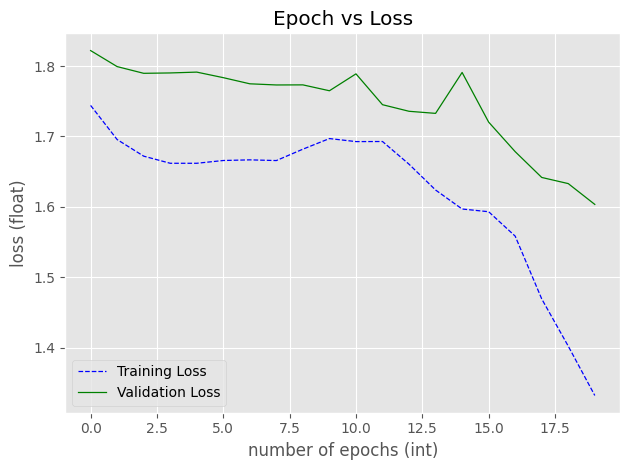

In [78]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.title("Epoch vs Loss")
plt.plot(range(num_epochs),list(training_loss.values()),linestyle="--",linewidth=0.9,color="blue",label="Training Loss")
plt.plot(range(num_epochs),list(validation_loss.values()),linestyle="-",linewidth=0.9,color="green",label="Validation Loss")
plt.xlabel("number of epochs (int)")
plt.ylabel("loss (float)")
plt.tight_layout()
plt.legend(loc="lower left")
plt.show()

In [79]:
for image,batch in val_loader:
    break

In [86]:
model.eval()
with torch.no_grad():
    cls,dist = model(image.to(device))
    preds = torch.argmax(cls,dim=1)
    

In [87]:
preds

tensor([ 0,  0, 41,  0,  0,  6,  0,  1,  0,  0,  9, 50, 78, 36, 78, 56, 77, 60,
        86, 74, 34, 65,  0,  0, 54, 18,  9,  0, 65, 18, 36, 91],
       device='cuda:0')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3760502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping i

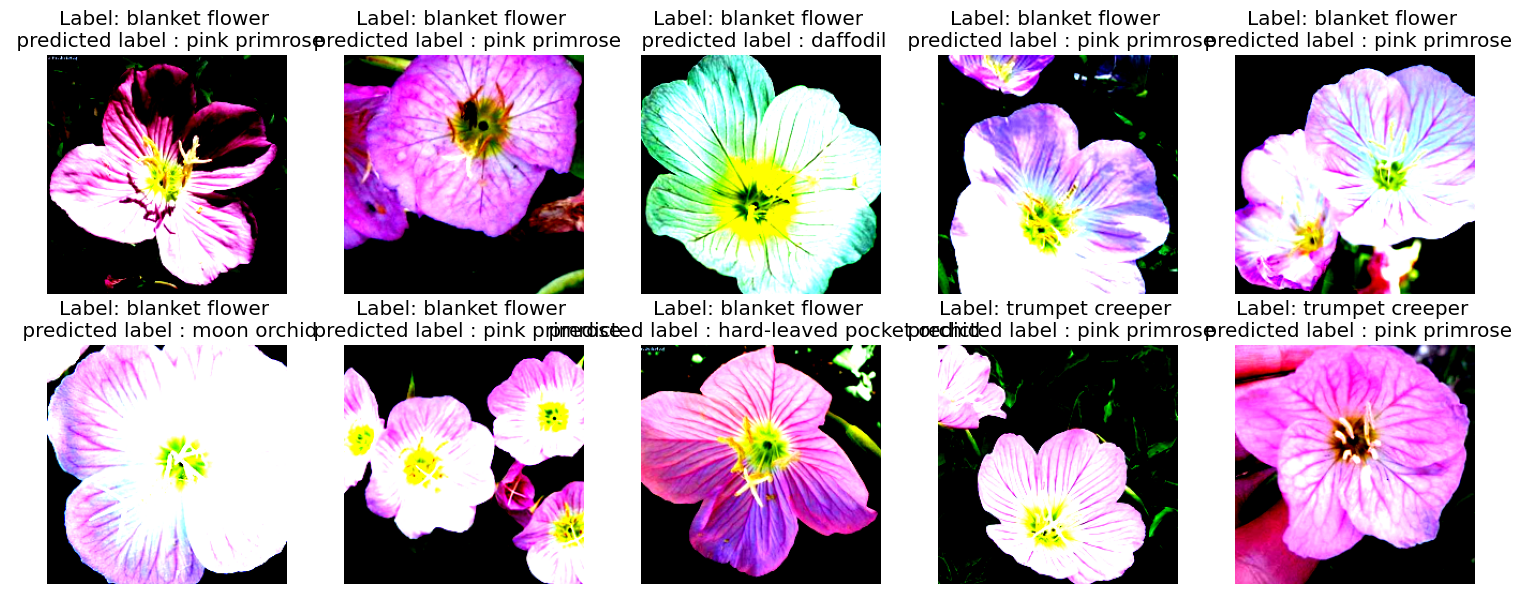

In [91]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing
for i in range(10):
    img = image[i].numpy().transpose((1, 2, 0))
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {oxford_flowers_classes[label[i].item()]} \n predicted label : {oxford_flowers_classes[preds[i]]}")
    axes[i].axis('off')  # Hide the x and y axes

plt.tight_layout()
plt.show()


## This is because the "resnet50" CNN is pretrained on imagenet dataset on spcifically on this "oxfardflowers102" dataset